In [1]:
from typing import (
    Callable,
    Dict,
    Tuple,
)
from itertools import repeat
from tqdm.notebook import tqdm

import torch
from torch import Tensor, nn
from torch.utils.data import DataLoader
from torchvision.transforms import v2
from sklearn.model_selection import train_test_split

from src import dataset
from src.models import mk_model
from src.dataset import load_preprocessed_dataset
from src.configs import TrainingConfig, ModelConfig, DatasetConfig, DEVICE, PIXEL_VALUE_CHANNEL_IDX

In [2]:

dataset.mk_dataset(verbose=False)
train_cfg = TrainingConfig(starting_lr=5e-2)
model_cfg = ModelConfig(
    channels=(32, 64, 128, 256, 512),
    strides=tuple(repeat(2, 4)),
    num_res_units=5,
)
dataset_cfg = DatasetConfig()

model = mk_model(model_cfg)
x_train, y_train, x_test = load_preprocessed_dataset()
x_ds = torch.utils.data.TensorDataset(torch.cat((x_train, x_test)[:1]).to(DEVICE))
x_dl = DataLoader(x_ds, train_cfg.batch_size)
ssl_transform = v2.RandomAffine(degrees=(-10, 10), translate=(0.1, 0.3), scale=(0.75, 1))
optimizer = torch.optim.Adam(model.parameters(), lr=train_cfg.starting_lr)

In [5]:
model

OptimizedModule(
  (_orig_mod): UNet(
    (model): Sequential(
      (0): ResidualUnit(
        (conv): Sequential(
          (unit0): Convolution(
            (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
            (adn): ADN(
              (N): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
              (D): Dropout(p=0.0, inplace=False)
              (A): LeakyReLU(negative_slope=0.01)
            )
          )
          (unit1): Convolution(
            (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (adn): ADN(
              (N): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
              (D): Dropout(p=0.0, inplace=False)
              (A): LeakyReLU(negative_slope=0.01)
            )
          )
          (unit2): Convolution(
            (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (adn): ADN(
 

  0%|          | 0/500 [00:00<?, ?it/s]

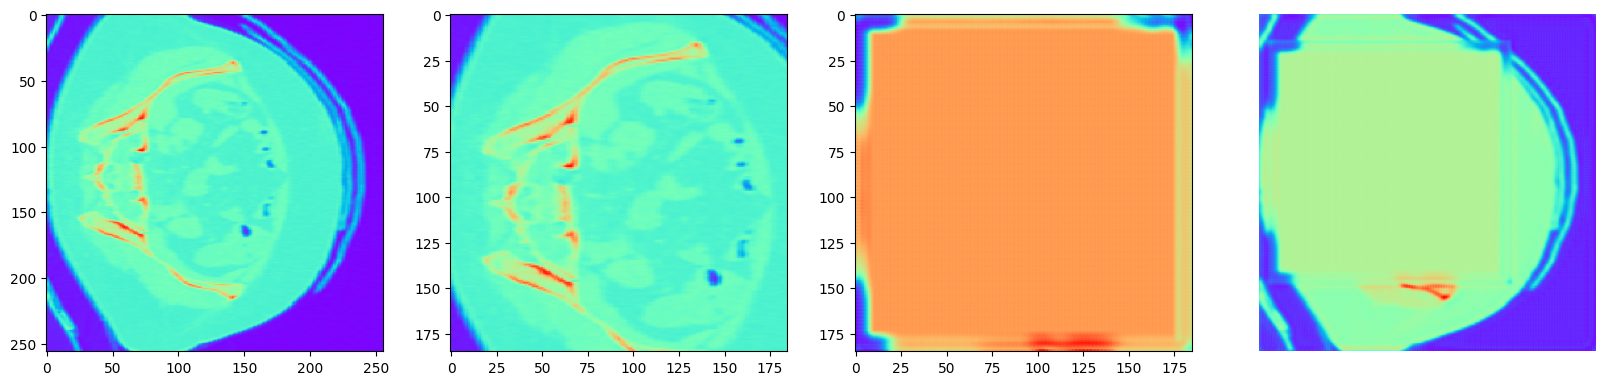

tensor(0.0770, device='cuda:0', grad_fn=<MseLossBackward0>)


In [3]:
from copy import deepcopy
from random import randint

import matplotlib.pyplot as plt


criterion_ret_t = Tuple[Tensor, Dict[str, Tensor]]
criterion_t = Callable[[Tensor, Tensor], criterion_ret_t]

N_REPEAT_STEPS = 1
def ssl_train_model_for_single_epoch(
        x_dl: DataLoader,
        model: nn.Module,
        optimizer: torch.optim.Optimizer,
        mask_size: int,
        transform: callable,
        plt=False
    ):
    (x, ) = next(iter(x_dl))[:1]
    x = x[:1]
    # print(x.shape)
    for i in range(1): #i, (x, ) in enumerate(x_dl):
        og_x = deepcopy(x)
        mask_slices = mk_mask_slices(mask_size)
        og_x = x.detach()
        x, x_target = get_augmeted_x_and_target(og_x, mask_slices, transform)

        def criterion(x_pred: Tensor, x_target: Tensor) -> criterion_ret_t:
            x_target_pred = x_pred[:, PIXEL_VALUE_CHANNEL_IDX, mask_slices[0], mask_slices[1]]
            # loss = torch.nn.functional.mse_loss(x_target_pred, x_target)
            # print(x_pred[:, PIXEL_VALUE_CHANNEL_IDX].shape, og_x.shape)
            loss = torch.nn.functional.mse_loss(x_pred[:, PIXEL_VALUE_CHANNEL_IDX], og_x[:, 0])
            # loss = (x_pred - x).abs().mean()
            return loss, {"mse_loss": loss, "x_target_pred": x_target_pred, "x_target": x_target}

        step_info, y_pred_logits = model_step(model, x, x_target, optimizer, criterion)
        if i == N_REPEAT_STEPS - 1 and plt:
            plt_step(
                og_x,
                # x,
                step_info["x_target"],
                step_info["x_target_pred"],
                y_pred_logits[:, PIXEL_VALUE_CHANNEL_IDX],
            )
            print(step_info["mse_loss"])

def model_step(
        model: nn.Module,
        x: Tensor,
        y_true: Tensor,
        optimizer: torch.optim.Optimizer,
        criterion: criterion_t
    ) -> dict[str, Tensor]:
    optimizer.zero_grad()
    # with torch.autocast(device_type=DEVICE.type, dtype=torch.bfloat16):
    y_pred_logits = model(x)
    loss, losses = criterion(y_pred_logits, y_true)
    loss.backward()
    # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    return losses, y_pred_logits

MAX_SAMPLES_TO_PLOT = 1
def plt_step(*tensors: list[Tensor]):
    b_size = tensors[0].shape[0]
    b_size = min(b_size, MAX_SAMPLES_TO_PLOT)
    fig, axes = plt.subplots(
        b_size,
        len(tensors),
        squeeze=False,
    )
    fig = fig.set_size_inches(5 * len(tensors), 10)
    for tensor_idx, tensor in enumerate(tensors):
        samples = tensor[:b_size]
        for sample_idx, sample in enumerate(samples):
            ax = axes[sample_idx, tensor_idx]
            sample = (
                sample
                .squeeze()
                .detach()
                .to(device="cpu", dtype=torch.float)
                .numpy()
            )
            ax.imshow(sample, cmap="rainbow")
    plt.axis("off")
    plt.show()

def get_augmeted_x_and_target(
        x: Tensor,
        mask_slices: tuple[slice, slice],
        transform: v2.Transform,
    ) -> tuple[Tensor, Tensor]:
    # x = transform(x)
    x_target = deepcopy(x[:, 0, mask_slices[0], mask_slices[1]]).detach()
    x = deepcopy(x)
    x[:, 0, mask_slices[0], mask_slices[1]] = 0
    return x, x_target

def mk_mask_slices(mask_size: int) -> tuple[slice, slice]:
    h_start = randint(0, 256 - mask_size)
    w_start = randint(0, 256 - mask_size)
    w_slice = slice(h_start, h_start + mask_size)
    h_slice = slice(w_start, w_start + mask_size)
    return w_slice, h_slice


PATCH_SIZE = 185

for _ in tqdm(range(500)):
    ssl_train_model_for_single_epoch(x_dl, model, optimizer, PATCH_SIZE, ssl_transform)
ssl_train_model_for_single_epoch(x_dl, model, optimizer, PATCH_SIZE, ssl_transform, True)

  0%|          | 0/500 [00:00<?, ?it/s]

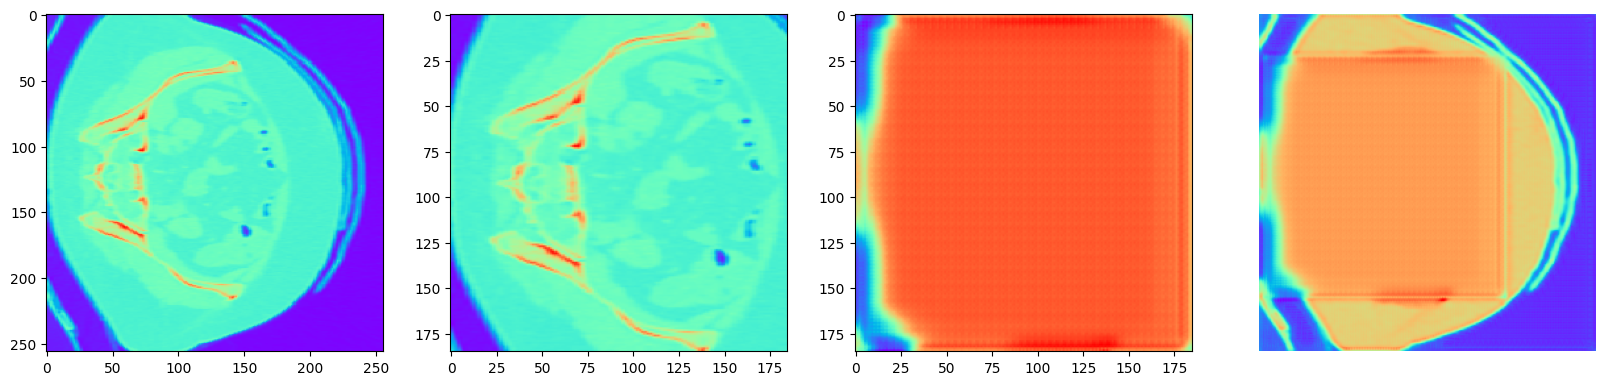

tensor(0.0749, device='cuda:0', grad_fn=<MseLossBackward0>)


In [4]:
for _ in tqdm(range(500)):
    ssl_train_model_for_single_epoch(x_dl, model, optimizer, PATCH_SIZE, ssl_transform)
ssl_train_model_for_single_epoch(x_dl, model, optimizer, PATCH_SIZE, ssl_transform, True)